# Olympic schedule

Contribution to #TidyTuesday week 10/02/2026

In [1]:
#setup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

In [2]:
#data processing
df = pd.read_csv("schedule.csv")

# Adjust start and end times to the nearest 30-minute interval
def round_to_nearest_half_hour(dt):
    minutes = dt.minute
    if minutes < 15:
        dt = dt.replace(minute=0, second=0, microsecond=0)
    elif minutes < 45:
        dt = dt.replace(minute=30, second=0, microsecond=0)
    else:
        dt = dt.replace(minute=0, second=0, microsecond=0) + pd.Timedelta(hours=1)
    return dt

df['start_datetime_local'] = pd.to_datetime(df['start_datetime_local'])
df['end_datetime_local'] = pd.to_datetime(df['end_datetime_local'])

df['start_datetime_rounded'] = df['start_datetime_local'].apply(round_to_nearest_half_hour)
df['end_datetime_rounded'] = df['end_datetime_local'].apply(round_to_nearest_half_hour)

In [3]:
#prepare data for heatmap

#include only competitions
competition_data = df[df['is_training'] == False].copy()

#set start and end date
first_start_date = "2026-02-04 00:00:00+00:00"
latest_end_date = "2026-02-22 23:59:00+00:00"

#get total hours by discipline
competition_data.loc[:, 'event_duration'] = (competition_data['end_datetime_local'] - 
                                             competition_data['start_datetime_local']).dt.total_seconds() / 3600
total_hours_by_discipline = competition_data.groupby('discipline_name')['event_duration'].sum()

# Get 30-minute intervals between the first and last date
time_intervals = pd.date_range(start=first_start_date, end=latest_end_date, freq='30T')

# DataFrame to hold the mapping
heatmap_df = pd.DataFrame(index=time_intervals)

# Iterate through each discipline and map 0 or 1 for each time interval
for discipline in total_hours_by_discipline.sort_values(ascending=False).index:
    discipline_data = competition_data[competition_data['discipline_name'] == discipline]
    discipline_series = pd.Series(0, index=time_intervals)
    
    for _, row in discipline_data.iterrows():
        mask = (time_intervals >= row['start_datetime_rounded']) & (time_intervals < row['end_datetime_rounded'])
        discipline_series[mask] = 1
    
    heatmap_df[discipline] = discipline_series

heatmap_df.head()

C:\Users\Lisa.Hornung\AppData\Local\Temp\ipykernel_17032\140874890.py:16: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  time_intervals = pd.date_range(start=first_start_date, end=latest_end_date, freq='30T')


,Curling,Ice Hockey,Figure Skating,Freestyle Skiing,Snowboard,Alpine Skiing,Cross-Country Skiing,Speed Skating,Bobsleigh,Ski Jumping,Biathlon,Skeleton,Luge,Short Track Speed Skating,Nordic Combined,Ski Mountaineering
2026-02-04 00:00:00+00:00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2026-02-04 00:30:00+00:00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2026-02-04 01:00:00+00:00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2026-02-04 01:30:00+00:00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2026-02-04 02:00:00+00:00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [4]:
#params for plot

#colours
transparent_to_color = LinearSegmentedColormap.from_list(
    "transparent_to_color",
    [
        (0.0, (1, 1, 1, 0.0)),  
        (1.0, (1, 1, 1, 1.0)),  
    ]
)

#font
from pyfonts import load_google_font
font_t = load_google_font("Poppins", weight="semi-bold", italic=False)
font_l = load_google_font("Poppins", weight="regular", italic=False)
font_st = load_google_font("Nanum Pen Script", weight="regular", italic=False)


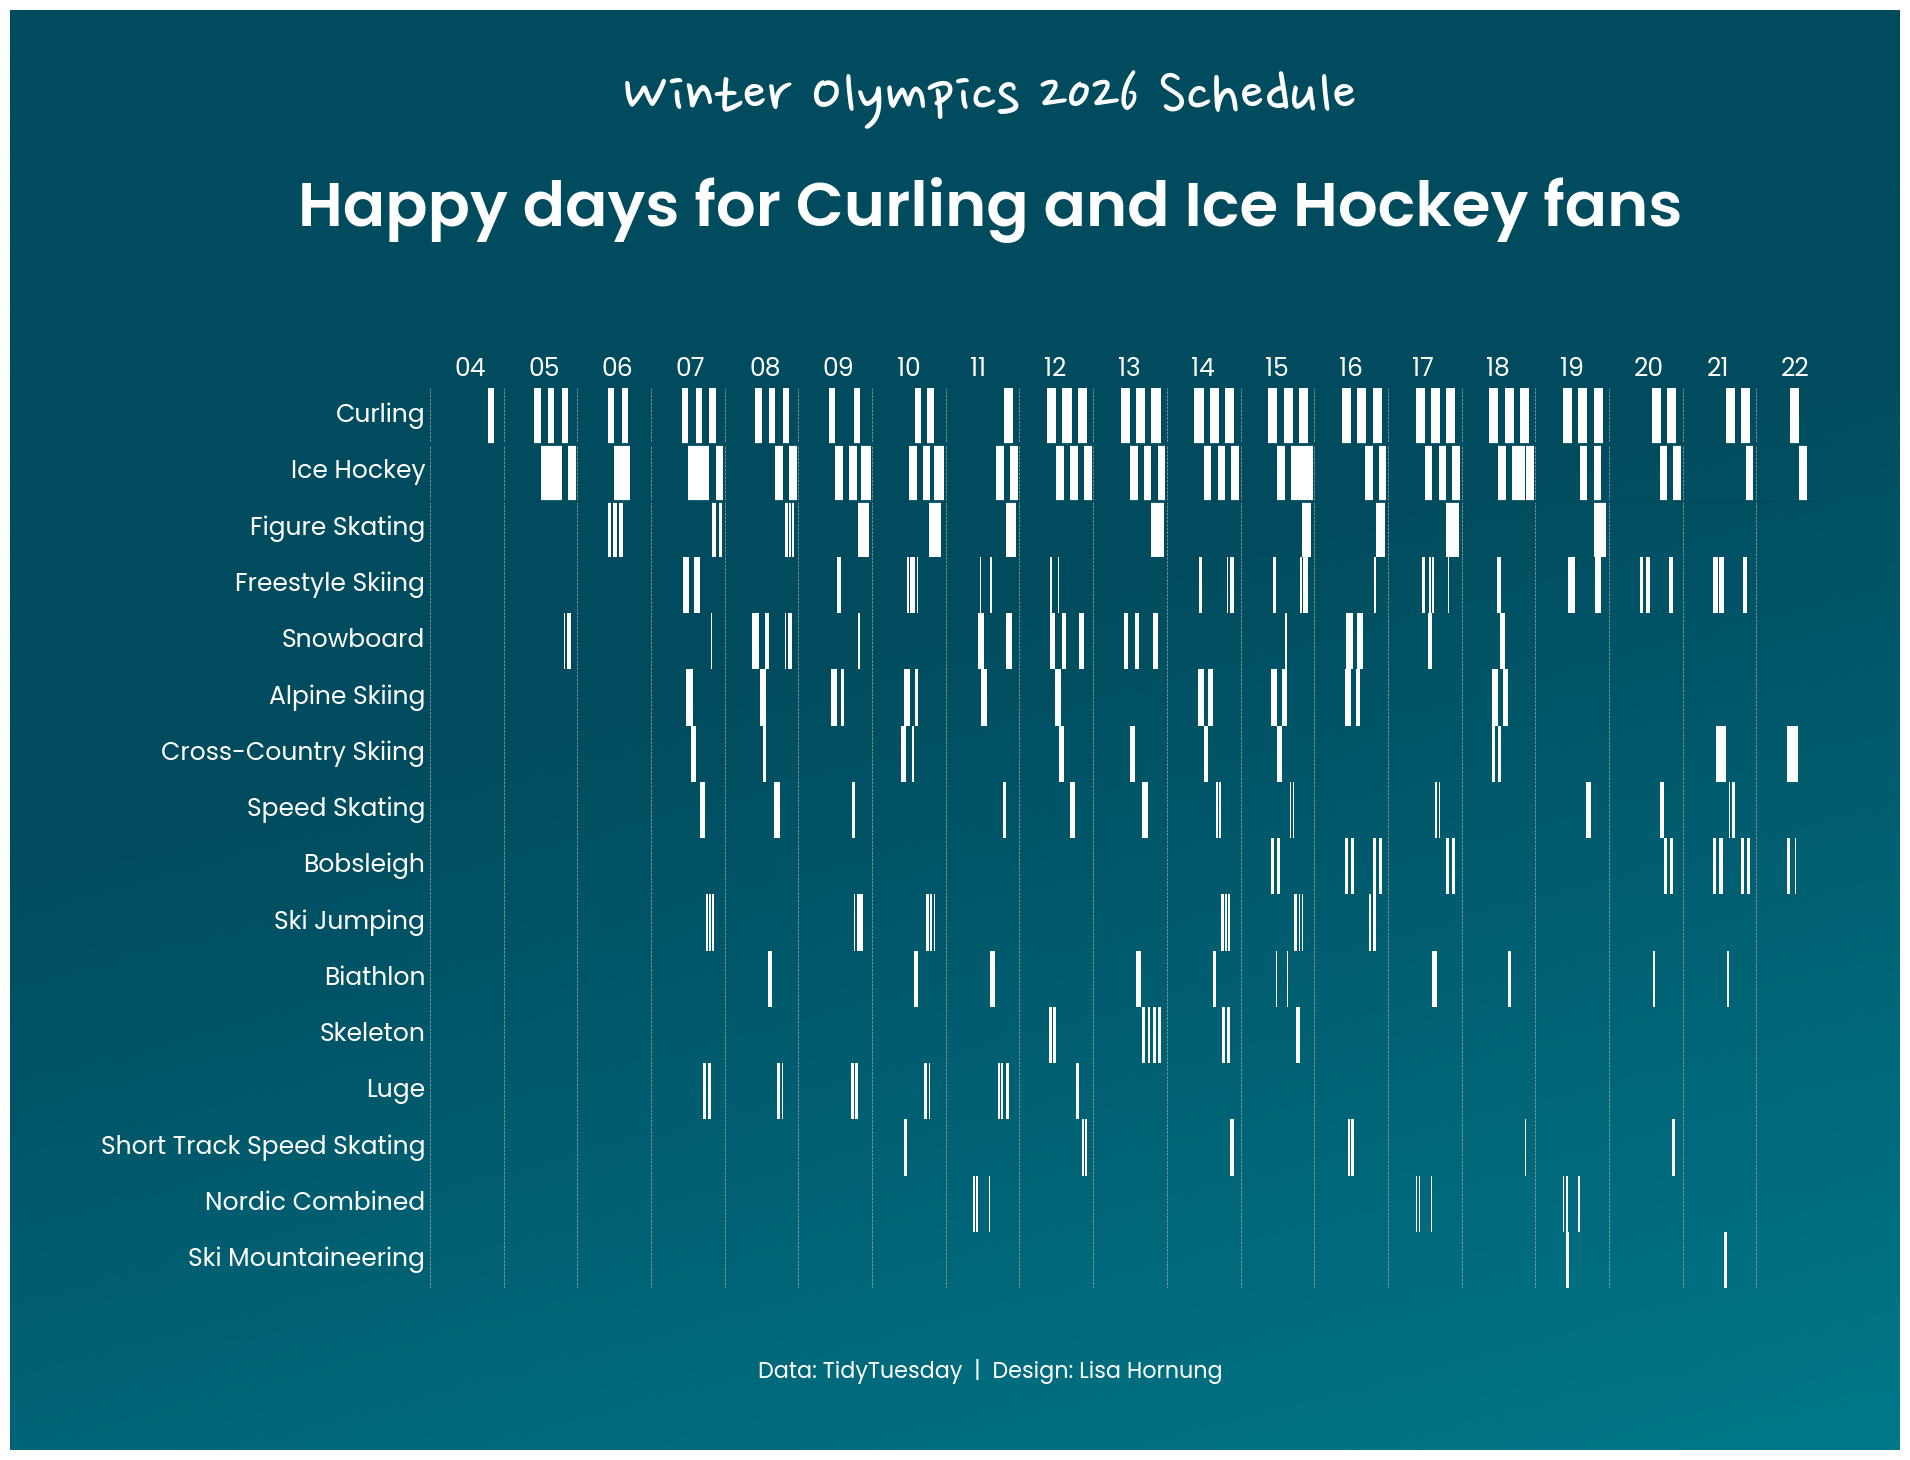

In [5]:
#Heatmap
fig, ax = plt.subplots(figsize=(14, 9))
ax.axis("off")

# add background image
im = plt.imread('background3.png')
bax = fig.add_axes([-0.3,-0.18, 1.35, 1.6], anchor='SW',zorder=1)
bax.imshow(im, aspect='auto', zorder=0)
bax.axis('off')

#==== Heatmap
dax = fig.add_axes([0, 0, 1, 1], zorder=2)
sns.heatmap(
    heatmap_df.T, 
    cmap=transparent_to_color,
    cbar=False,
    linewidths=0.0,
    ax=dax,
    square=False,
)
dax.set_facecolor("none")
dax.patch.set_alpha(0)
fig.patch.set_alpha(0)

#==== xaxis
# Set x-axis ticks for midnight times
midnight_times = heatmap_df.index[heatmap_df.index.time == pd.Timestamp('00:00:00').time()].tolist()
midnight_positions = [heatmap_df.index.get_loc(t) for t in midnight_times]

# Offset tick positions
offset = 16 
shifted_positions = [pos + offset for pos in midnight_positions]
dax.set_xticks(shifted_positions)
dax.set_xticklabels([time.strftime('%d') for time in midnight_times], rotation=0, ha='left', 
                    font=font_l, fontsize=18, color="white")
dax.xaxis.tick_top()
dax.tick_params(axis="x", length=0)

for pos in midnight_positions:
    dax.axvline(x=pos, color='#aeaeae', linestyle='--', linewidth=0.5)


#==== yaxis
dax.tick_params(axis="y", length=0)
dax.set_yticklabels(dax.get_yticklabels(), rotation=0, 
                    font=font_l, fontsize=18, color="white")

num_rows = heatmap_df.T.shape[0]
for y in range(1, 3):
    dax.axhline(y=y, color="#004C5E", linestyle="solid", linewidth=2)

#=== titles
plt.figtext(0.4,1.18, "Happy days for Curling and Ice Hockey fans", 
            color="white", 
            ha="center",
            font=font_t, fontsize=45)
plt.figtext(0.4,1.3, "Winter Olympics 2026 Schedule", 
            color="white", 
            ha="center",
            font=font_st, fontsize=50)
plt.figtext(0.4,-0.1, "Data: TidyTuesday  |  Design: Lisa Hornung", 
            color="white", 
            ha="center",
            font=font_l, fontsize=16)


#plt.savefig("olympics-schedule.svg")
plt.savefig("olympics-schedule.png", bbox_inches='tight')

plt.show()